In [43]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
from vis_utils.loaders import load_dataset
import matplotlib.pyplot as plt
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from openTSNE.affinity import Affinities
from vis_utils.tsne_wrapper import TSNEwrapper
import umap
from ripser import Rips

from mpl_toolkits.axes_grid1 import make_axes_locatable
from ripser.ripser import get_greedy_perm
from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

import matplotlib.pyplot as plt
from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print
from vis_utils.plot import plot_scatter
import os
from sklearn.decomposition import PCA

from persim import plot_diagrams

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


In [2]:
root_path = get_path("data")
fig_path = os.path.join(root_path, "figures")
seeds = [0, 1, 2]
k = 15

In [3]:
style_file = "utils.style"
plt.style.use(style_file)

In [4]:
outlier_clusters = ["Sst Chodl", # middle top
                    "Pvalb Gabrg1", # bottom right
                    "Pvalb Vipr2", # middle right
                    ]

In [5]:
distances = {
    "euclidean": [{}],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 250, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 500, "disconnect": True},
    ],
}

In [6]:
n_epochs = 500
n_early_epochs = 250
perplexity = None
rescale_tsne = True
seed = 0
file_name = os.path.join(root_path,
                         "tasic",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

In [7]:
_, _, _, _, full_d = load_dataset(root_path, "tasic", k=k)

In [8]:
mask_Pvalb = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Pvalb")
mask_Sst = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Sst")
mask_orange = np.maximum(mask_Pvalb, mask_Sst)
n_orange = mask_orange.sum()

In [ ]:
mask_outlier = embd[mask_orange][:, 1] > 0

In [9]:
mask_Vip = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Vip")
mask_Sncg = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Sncg")
mask_Serpinf1 = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Serpinf1")

mask_purple = mask_Vip | mask_Sncg | mask_Serpinf1

# Tasic orange

In [108]:
dataset = "tasic_orange"

In [109]:
x, y, sknn, pca2, d = load_dataset(root_path, dataset, k=k, seed=0)

In [110]:
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

Done with tasic_orange None euclidean n_outliers=0
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_250_disconnect_True n_outliers=0
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_500_disconnect_True n_outliers=0


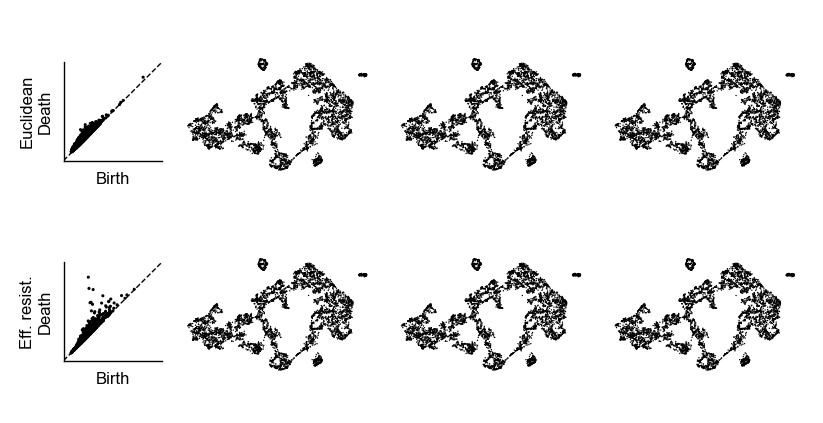

In [66]:
n_exp = sum([len(all_res[distance]) for distance in distances.keys()])

n_cols = 4
plot_loops = False

width_ratios = [0.5] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=2, ncols=n_cols, figsize=(4, 2), constrained_layout=True, width_ratios=width_ratios)
seed = 0
size = 1

for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        if distance == "eff_res" and "k_100" not in full_dist: continue
        res = all_res[distance][full_dist][seed]
        
        # todo change n_loops to something other than 0 to actually see some loops
        plot_dgm_loops(res, embd=embd[mask_orange], y="k", n_loops=0, ax=ax[i], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)
        
        for s in range(n_cols-1):
            ax[i][s+1].set_ylim(-80, -10)
        
        ax[i][0].legend().set_visible(False)
        ax[i][0].set_xticks([])
        ax[i][0].set_yticks([])
        ax[i][0].set_ylabel(f"{dist_to_print[distance]}\nDeath")
        
fig.savefig(os.path.join(fig_path, f"tasic_orange_dgms_eff_res_eucl_no_loops.png"), dpi=300)

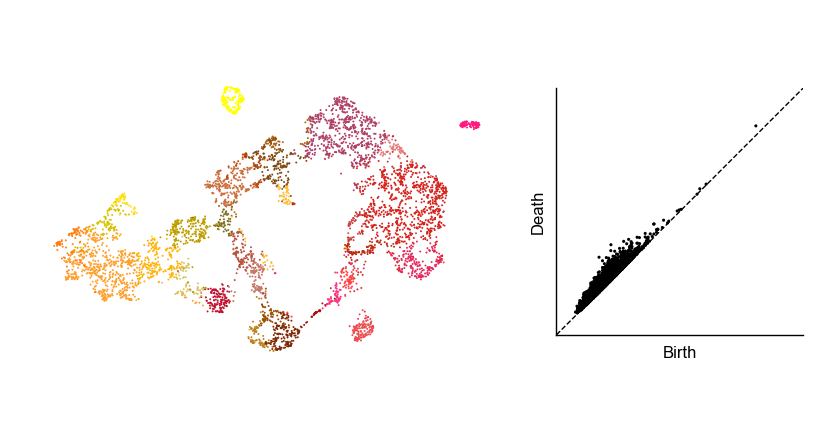

In [111]:
n_cols = 2
plot_loops = False

width_ratios = [0.5] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=1, ncols=n_cols, figsize=(4, 2), constrained_layout=True, width_ratios=width_ratios[::-1])
seed = 0
size = 1

distance = "euclidean"
full_dist = "euclidean"

res = all_res[distance][full_dist][seed]

plot_dgm_loops(res, embd=embd[mask_orange], y=d['clusterColors'][d['clusters']], n_loops=0, ax=ax[::-1], s=2, plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)

for s in range(n_cols-1):
    ax[s].set_ylim(-80, -10)

ax[1].legend().set_visible(False)
ax[1].set_xticks([])
ax[1].set_yticks([])
        
fig.savefig(os.path.join(fig_path, f"tasic_orange_dgms_eucl_no_loops.png"), dpi=300)

# Tasic purple

In [112]:
dataset = "tasic_purple"

In [113]:
x, y, sknn, pca2, d = load_dataset(root_path, dataset, k=k, seed=0)

In [114]:
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

Done with tasic_purple None euclidean n_outliers=0
Done with tasic_purple None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0
Done with tasic_purple None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0
Done with tasic_purple None eff_res_corrected_True_weighted_False_k_250_disconnect_True n_outliers=0
Done with tasic_purple None eff_res_corrected_True_weighted_False_k_500_disconnect_True n_outliers=0


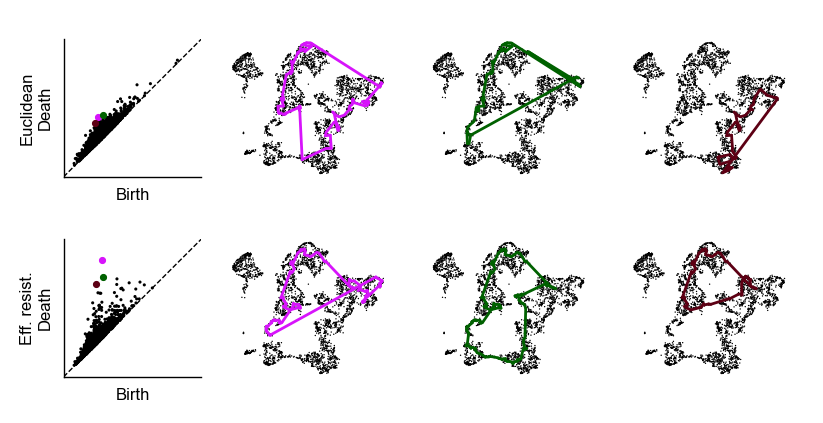

In [117]:
n_exp = sum([len(all_res[distance]) for distance in distances.keys()])

n_cols = 4
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=2, ncols=n_cols, figsize=(4, 2), constrained_layout=True, width_ratios=width_ratios)
seed = 0
size = 1

for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        if distance == "eff_res" and "k_15" not in full_dist: continue
        res = all_res[distance][full_dist][seed]
        
        plot_dgm_loops(res, embd=embd[mask_purple], y="k", n_loops=0, ax=ax[i], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)
        
        
        for s in range(n_cols-1):
            ax[i][s+1].set_xlim(25, 85)
        
        ax[i][0].legend().set_visible(False)
        ax[i][0].set_xticks([])
        ax[i][0].set_yticks([])
        ax[i][0].set_ylabel(f"{dist_to_print[distance]}\nDeath")
        
fig.savefig(os.path.join(fig_path, f"tasic_purple_dgms_eff_res_eucl.png"), dpi=300)

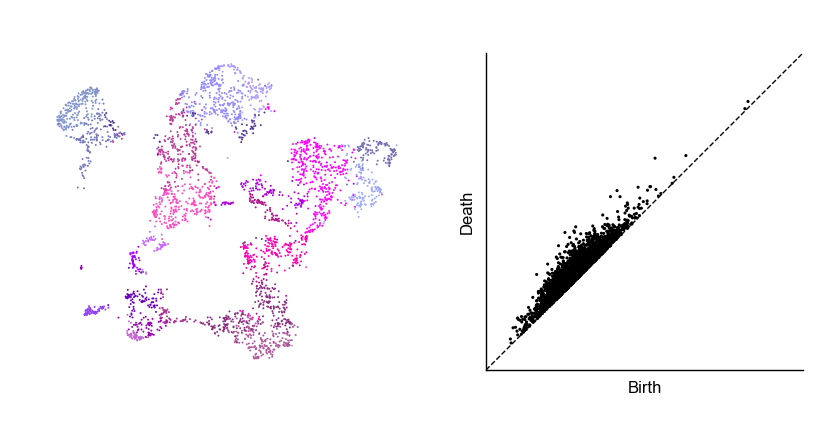

In [116]:
n_cols = 2
plot_loops = False

width_ratios = [0.75] + [1] * (n_cols - 1)

fig, ax = plt.subplots(nrows=1, ncols=n_cols, figsize=(4, 2), constrained_layout=True, width_ratios=width_ratios[::-1])
seed = 0
size = 1

distance = "euclidean"
full_dist = "euclidean"

res = all_res[distance][full_dist][seed]

plot_dgm_loops(res, embd=embd[mask_purple], y=d['clusterColors'][d['clusters']], n_loops=0, ax=ax[::-1], plot_only=[1],
               style=style_file, linewidth=1, plot_loops=plot_loops, s=2)

for s in range(n_cols - 1):
    ax[s].set_xlim(25, 85)

ax[1].legend().set_visible(False)
ax[1].set_xticks([])
ax[1].set_yticks([])

fig.savefig(os.path.join(fig_path, f"tasic_purple_dgms_eucl_no_loops.png"), dpi=300)